In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing  import StandardScaler

In [2]:
df = pd.read_csv(r"C:\Users\PC\Downloads\loan_data.csv")
df.head(3)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0


In [3]:
_dict = {
    col: df[col].unique()
    for col in df.select_dtypes(include='object').columns
}
_dict

{'Gender': array(['Female', 'Male', nan], dtype=object),
 'Married': array(['No', 'Yes', nan], dtype=object),
 'Dependents': array(['0', '3+', '2', '1', nan], dtype=object),
 'Education': array(['Graduate', 'Not Graduate'], dtype=object),
 'Self_Employed': array(['No', 'Yes', nan], dtype=object),
 'Property_Area': array(['Semiurban', 'Rural', 'Urban'], dtype=object)}

In [4]:
df.isnull().sum()

Gender               10
Married               1
Dependents            9
Education             0
Self_Employed        29
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           16
Loan_Amount_Term     13
Credit_History       43
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce')
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].median())
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

In [6]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [7]:
le = LabelEncoder()

cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

for col in cols:
    df[col] = le.fit_transform(df[col])

In [8]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,0,0.0,0,0,4547,0.0,115.0,360.0,1.0,1,1
1,1,1,3.0,1,1,5703,0.0,130.0,360.0,1.0,0,1
2,0,1,0.0,0,0,4333,2451.0,110.0,360.0,1.0,2,0
3,1,1,0.0,1,1,4695,0.0,96.0,360.0,1.0,2,1
4,1,1,2.0,0,0,6700,1750.0,230.0,300.0,1.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
486,1,1,1.0,0,1,9833,1833.0,182.0,180.0,1.0,2,1
487,0,0,1.0,0,0,3812,0.0,112.0,360.0,1.0,0,1
488,1,1,1.0,0,0,14583,0.0,185.0,180.0,1.0,0,1
489,1,0,0.0,0,0,1836,33837.0,90.0,360.0,1.0,2,0


<Axes: xlabel='Gender', ylabel='count'>

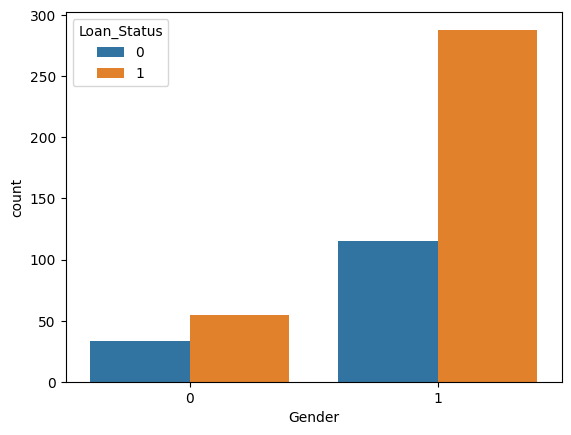

In [9]:
sns.countplot(data = df, x = "Gender", hue = "Loan_Status")

<Axes: xlabel='Credit_History', ylabel='count'>

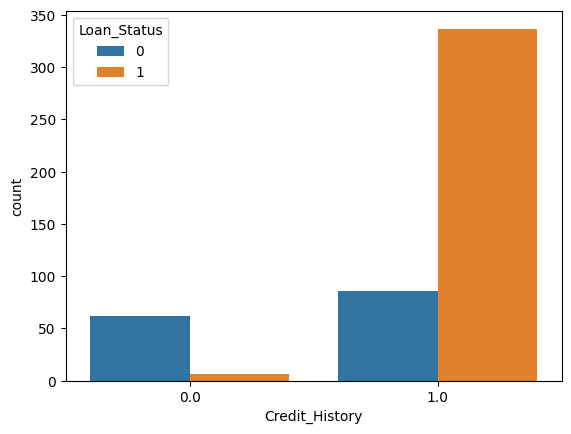

In [10]:
sns.countplot(data = df, x = "Credit_History", hue = "Loan_Status")

<Axes: xlabel='Property_Area', ylabel='count'>

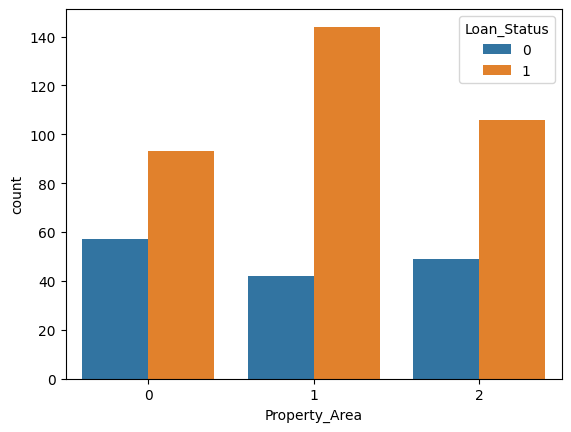

In [11]:
sns.countplot(data = df, x = "Property_Area", hue = "Loan_Status")


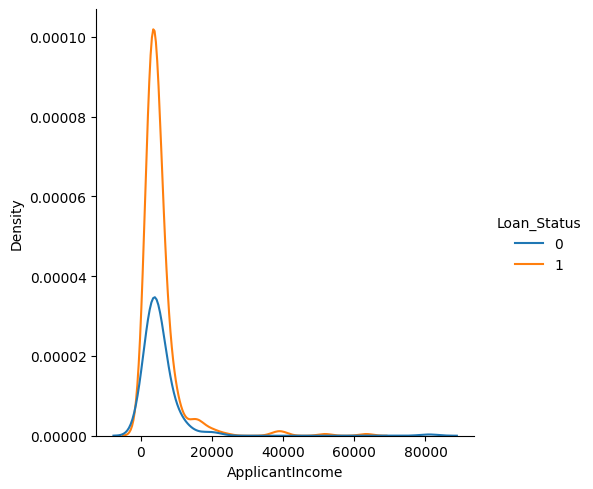

In [12]:
sns.displot(data=df, x="ApplicantIncome",hue=df["Loan_Status"],kind="kde")

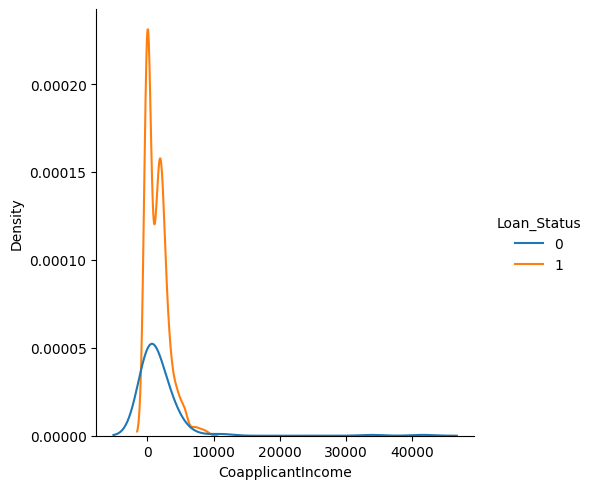

In [13]:
sns.displot(data=df, x="CoapplicantIncome",hue=df["Loan_Status"],kind="kde")

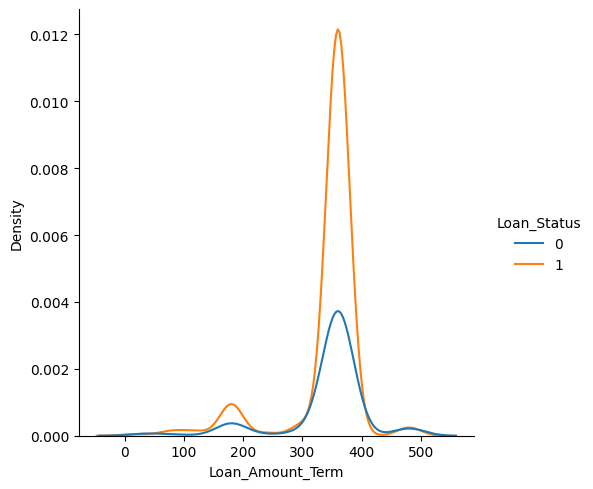

In [14]:
sns.displot(data=df, x="Loan_Amount_Term",hue=df["Loan_Status"],kind="kde")

In [40]:
X = df.drop('Loan_Status',axis=1)
y = df["Loan_Status"]

In [41]:
X

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,0,0,0.0,0,0,4547,0.0,115.0,360.0,1.0,1
1,1,1,3.0,1,1,5703,0.0,130.0,360.0,1.0,0
2,0,1,0.0,0,0,4333,2451.0,110.0,360.0,1.0,2
3,1,1,0.0,1,1,4695,0.0,96.0,360.0,1.0,2
4,1,1,2.0,0,0,6700,1750.0,230.0,300.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...
486,1,1,1.0,0,1,9833,1833.0,182.0,180.0,1.0,2
487,0,0,1.0,0,0,3812,0.0,112.0,360.0,1.0,0
488,1,1,1.0,0,0,14583,0.0,185.0,180.0,1.0,0
489,1,0,0.0,0,0,1836,33837.0,90.0,360.0,1.0,2


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [43]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Credit_History       0.223471
ApplicantIncome      0.214022
LoanAmount           0.197832
CoapplicantIncome    0.114345
Property_Area        0.058527
Dependents           0.047534
Loan_Amount_Term     0.040285
Education            0.031895
Married              0.028922
Gender               0.022858
Self_Employed        0.020309
dtype: float64


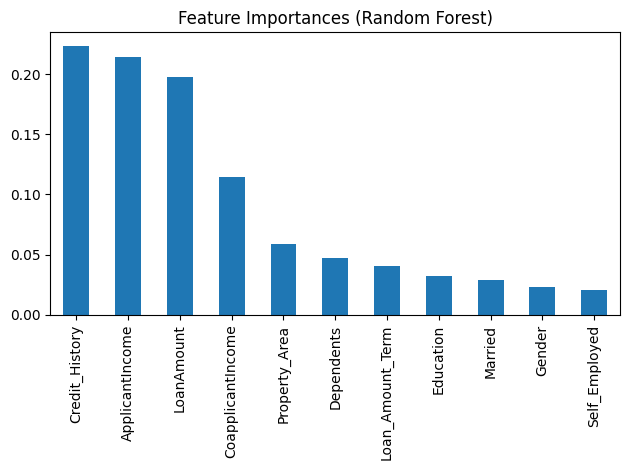

In [44]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)
importances.plot(kind='bar')
plt.title("Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

#### IMPORANT FEATURES

In [16]:
X = df[['Credit_History','ApplicantIncome','LoanAmount','CoapplicantIncome']]
y = df["Loan_Status"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [19]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [20]:
y_pred = lr.predict(X_test_scaled)

lr = LogisticRegression()
lr.fit(X_train,y_train)

In [22]:
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay,confusion_matrix

In [28]:
accuracy_score(y_test,y_pred)

0.8292682926829268

In [24]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[19, 18],
       [ 3, 83]], dtype=int64)

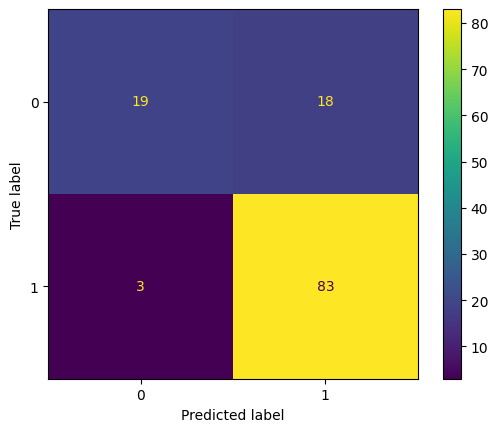

In [25]:
disp = ConfusionMatrixDisplay(cm)
disp.plot()

In [26]:
y_train.value_counts()

Loan_Status
1    257
0    111
Name: count, dtype: int64

In [27]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.51      0.64        37
           1       0.82      0.97      0.89        86

    accuracy                           0.83       123
   macro avg       0.84      0.74      0.77       123
weighted avg       0.83      0.83      0.81       123



In [29]:
import joblib

joblib.dump({
    "model": lr,
    "scaler": scaler
}, "loan_model.pkl")

['loan_model.pkl']